# LeetCode #401: Binary Watch

https://leetcode.com/problems/binary-watch/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (enumerate combinations)** | $O(\binom{10}{n})$ | $O(1)$ |
| **Optimal: Bit Manipulation (enumerate all times) ★** | $O(1)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (enumerate combinations)
Enumerate all $\binom{10}{n}$ subsets of the 10 LEDs, map each to an hour/minute and validate. Complex subset generation for no algorithmic gain.

### Optimal: Bit Manipulation (enumerate all times) ★
Loop over all valid times (h in 0..11, m in 0..59). For each, compute `popcount(h) + popcount(m)`. If the total equals `num`, add the formatted time to the result. The universe of valid times is only 720 combinations — effectively $O(1)$.

**Why this is better than Brute Force:** Direct iteration over valid times is simpler and avoids generating LED subsets entirely. Fixed 720 iterations regardless of `num`.

**Constraints:**
* $0 \le$ num $\le 9$

## Solutions

### C#

In [ ]:
using System.Numerics;

public IList<string> ReadBinaryWatch(int num) {
    var result = new List<string>();
    for (int h = 0; h < 12; h++) {
        for (int m = 0; m < 60; m++) {
            // Sum of set bits in hour and minute must equal num
            if (BitOperations.PopCount((uint)h) + BitOperations.PopCount((uint)m) == num)
                result.Add($"{h}:{m:D2}");
        }
    }
    return result;
}

### Python

In [ ]:
def readBinaryWatch(self, num: int) -> List[str]:
    result = []
    for h in range(12):
        for m in range(60):
            # Sum of set bits in hour and minute must equal num
            if bin(h).count('1') + bin(m).count('1') == num:
                result.append(f"{h}:{m:02d}")
    return result

### Go

In [ ]:
import (
    "fmt"
    "math/bits"
)

func readBinaryWatch(num int) []string {
    result := []string{}
    for h := 0; h < 12; h++ {
        for m := 0; m < 60; m++ {
            // Sum of set bits in hour and minute must equal num
            if bits.OnesCount(uint(h))+bits.OnesCount(uint(m)) == num {
                result = append(result, fmt.Sprintf("%d:%02d", h, m))
            }
        }
    }
    return result
}

### Rust

In [ ]:
pub fn read_binary_watch(num: i32) -> Vec<String> {
    let mut result = vec![];
    for h in 0u32..12 {
        for m in 0u32..60 {
            // Sum of set bits in hour and minute must equal num
            if (h.count_ones() + m.count_ones()) as i32 == num {
                result.push(format!("{}:{:02}", h, m));
            }
        }
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** num = 1
Hours with 1 bit: 1,2,4,8. Minutes with 1 bit: 1,2,4,8,16,32. Pairs where total = 1: (0,1),(0,2),(0,4),(0,8),(0,16),(0,32),(1,0),(2,0),(4,0),(8,0). Result: 10 times like ["0:01","0:02",...,"8:00"].

**2. Slightly Complex**
**Input:** num = 2
Need popcount(h)+popcount(m)=2. E.g. h=0 (0 bits), m with 2 bits: 3,5,6,9,...; h=1 (1 bit), m with 1 bit: 1,2,4,...; h=3 (2 bits), m=0. Produces a larger list of valid times.

**3. Edge Case: Time Factor**
**Input:** num = 0
Only 0:00 has total popcount=0. Single match out of 720 candidate times checked. Exactly 720 iterations run regardless of num.

**4. Edge Case: Space Factor**
**Input:** num = 9
Very few (or zero) valid times — most combinations of $h+m$ bits don't reach 9 (max is $3+6=9$ bits). Result list is tiny. The 720-iteration loop is the dominant cost; output is negligible.

**5. Almost-Impossible but Plausible**
**Input:** num = 10 (more bits than possible: max is 3+6=9)
No valid (h, m) pair has 10 set bits total. All 720 iterations complete without appending anything. Return **[]** — empty list. Tests the boundary where the answer is empty.

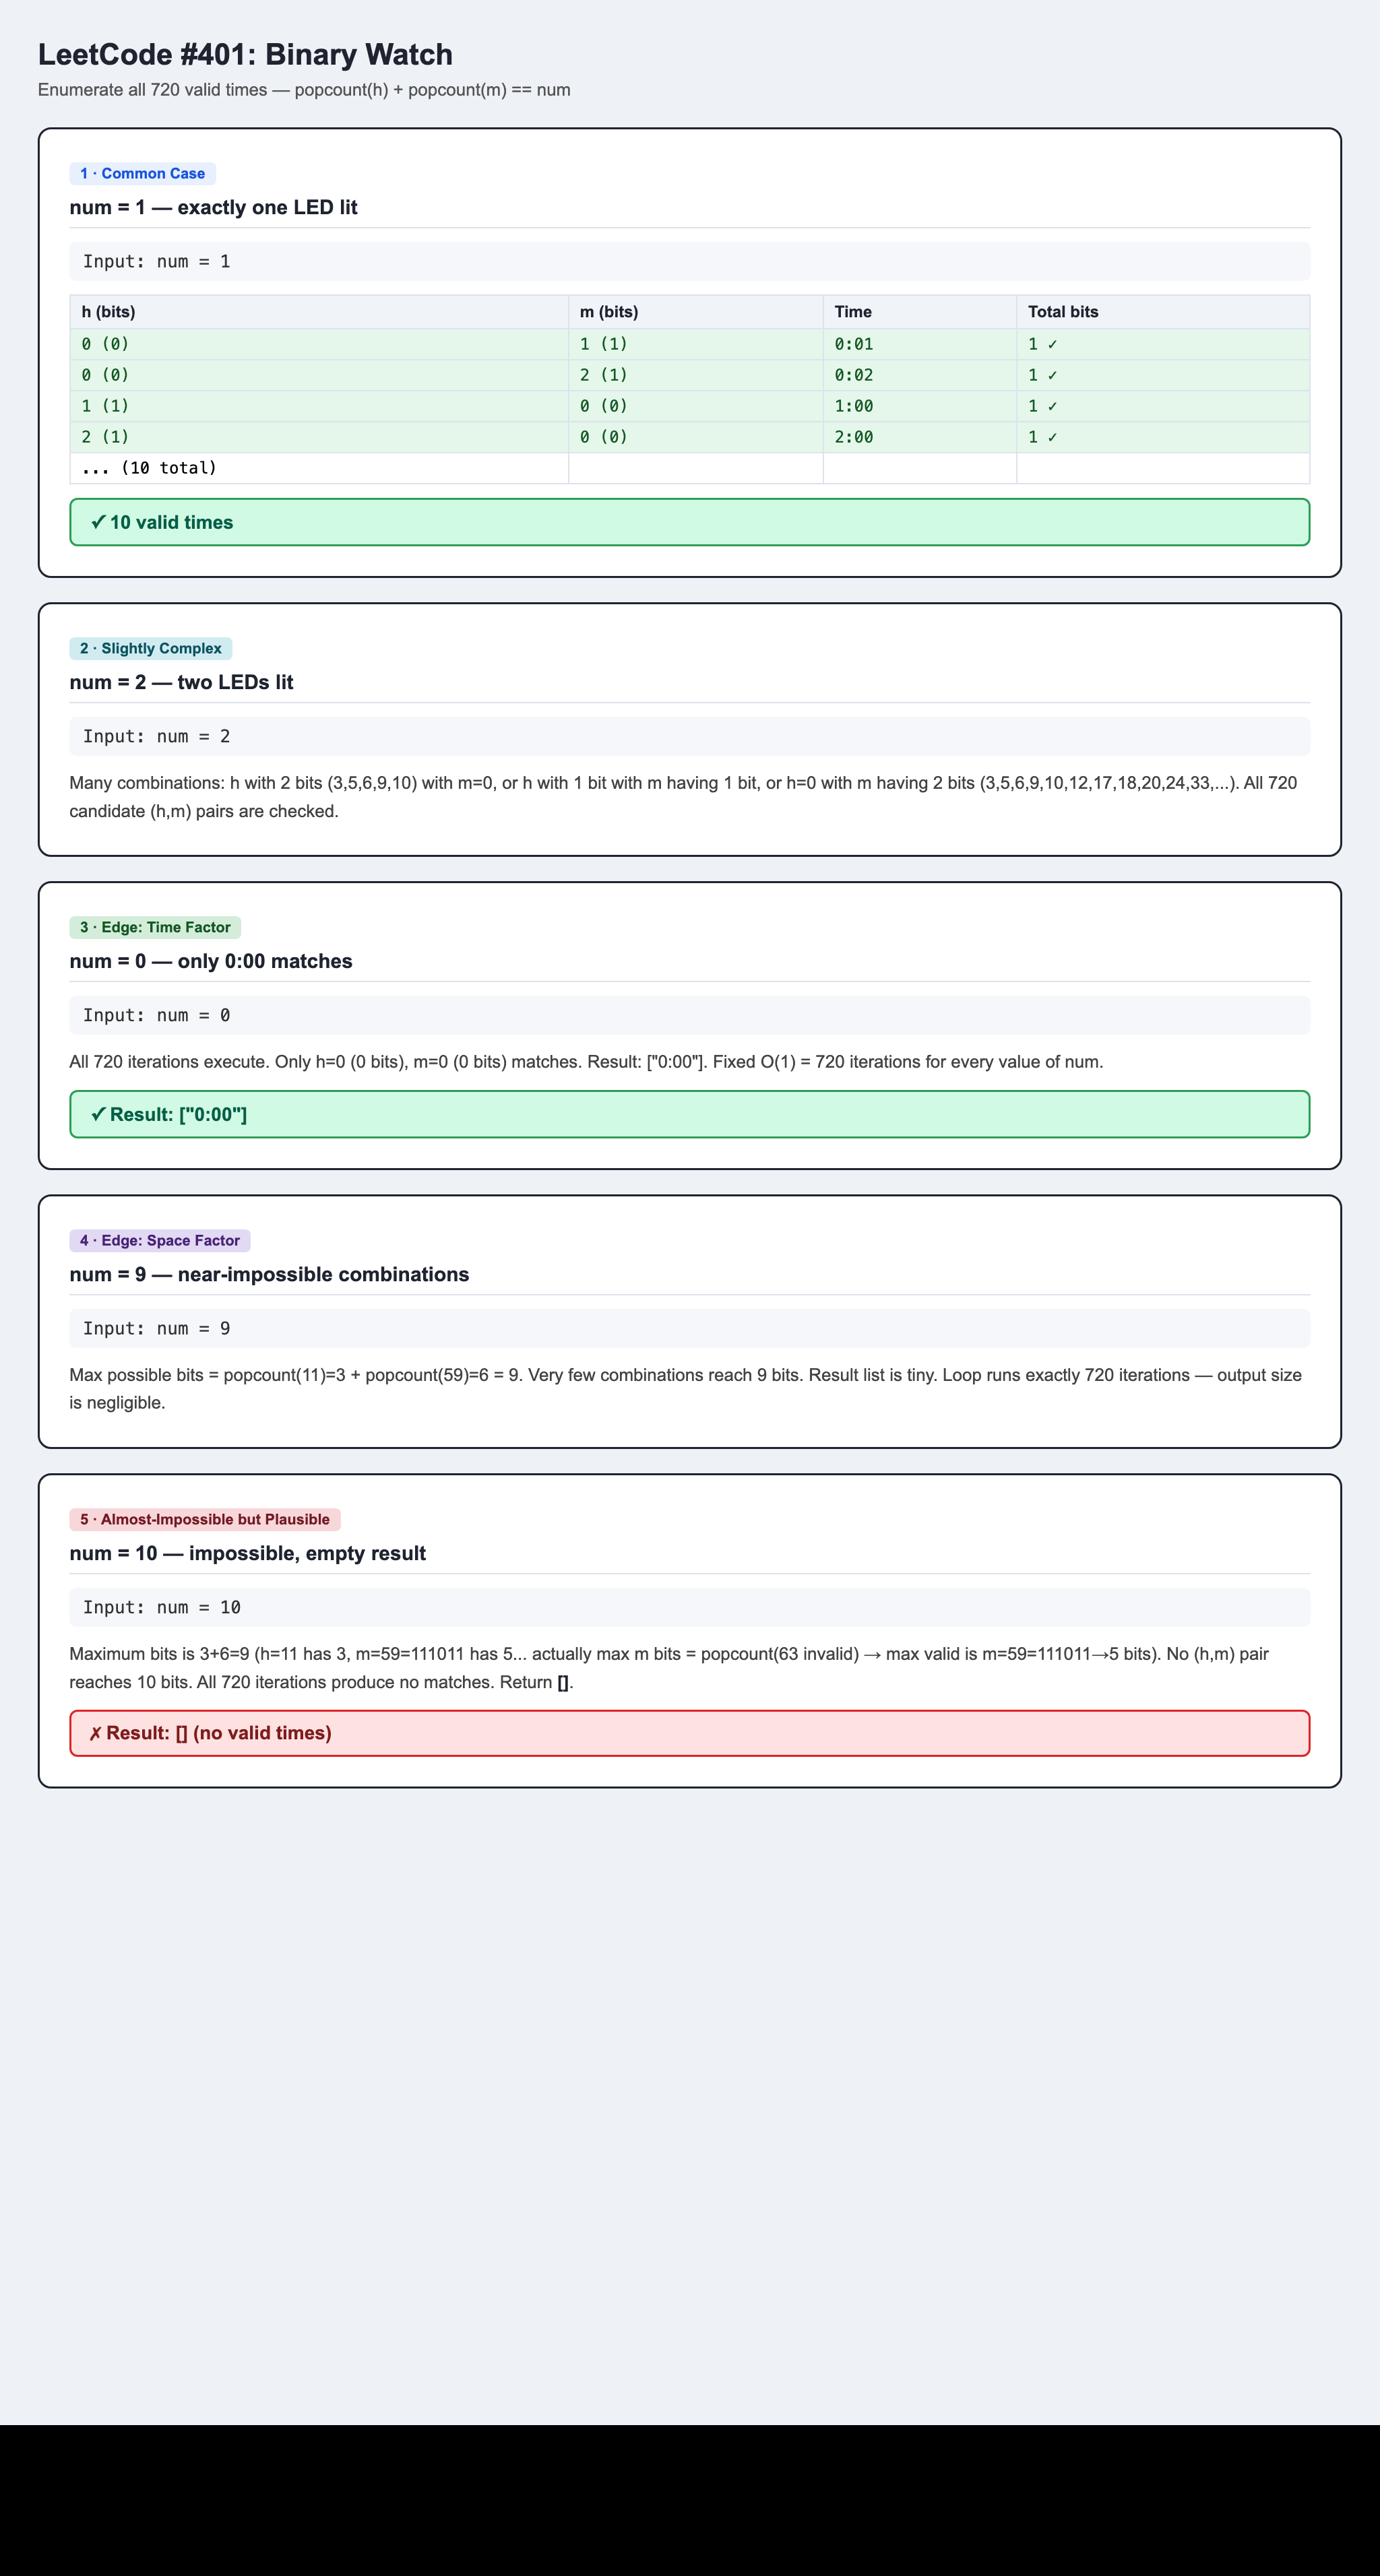